# Credit Risk Modelling — Probability of Default (PD) Model

### Project Overview
This project builds an end-to-end credit risk model using real-world loan application data 
from Home Credit Group. The goal is to predict the **Probability of Default (PD)** — the 
likelihood that a borrower will fail to repay their loan in 12 months.

The workflow follows industry standard practice used by bank credit risk teams:

1. **Exploratory Data Analysis (EDA)**: understand the data, default rates, missing values
2. **Feature Engineering**: Weight of Evidence (WoE) encoding, Information Value (IV) selection
3. **Logistic Regression Scorecard**: a points-based model interpretable by regulators
4. **Machine Learning Models**: XGBoost/LightGBM for comparison
5. **Model Validation**: KS statistic, Gini coefficient, Population Stability Index (PSI)
6. **Regulatory Context**: how this fits into the Basel II/III IRB framework

---

### Data

The data files are not included in this repository due to their size. Download them from the Kaggle competition:

**[Home Credit Default Risk — Kaggle](https://www.kaggle.com/competitions/home-credit-default-risk/data)**

Once downloaded, place the following files into a `data/` folder in the project root:

- `data/application_train.csv`
- `data/bureau.csv`

> You will need a free Kaggle account and to accept the competition rules before downloading.

---

**Dataset:** Home Credit Default Risk (Kaggle)  
**Target variable:** `TARGET` : 1 = defaulted, 0 = repaid

In [68]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing  
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

# WoE Binning 
import scorecardpy as sc

# ML Models (for comparison with scorecard) 
import xgboost as xgb
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')


pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid')



## Exploratory Data Analysis (EDA)

In [69]:
df = pd.read_csv('data/application_train.csv') 

print(f"Dataset shape: {df.shape}")
print(f"Number of applications: {df.shape[0]:}")
print(f"Number of features: {df.shape[1]:}")

Dataset shape: (307511, 122)
Number of applications: 307511
Number of features: 122


The dataset contains 122 features including demographic information, credit history, and loan details.

Due to the sensitive nature of credit risk modelling, all personally identifiable information (PII) has been removed from the dataset. The features are anonymized but still provide valuable insights for building predictive models.

We now look at the distribution of the target variable to understand the class imbalance in the dataset.

Target Variable Distribution
Non-Default (0): 282,686 (91.9%)
Default     (1): 24,825 (8.1%)

Default Rate: 8.07%


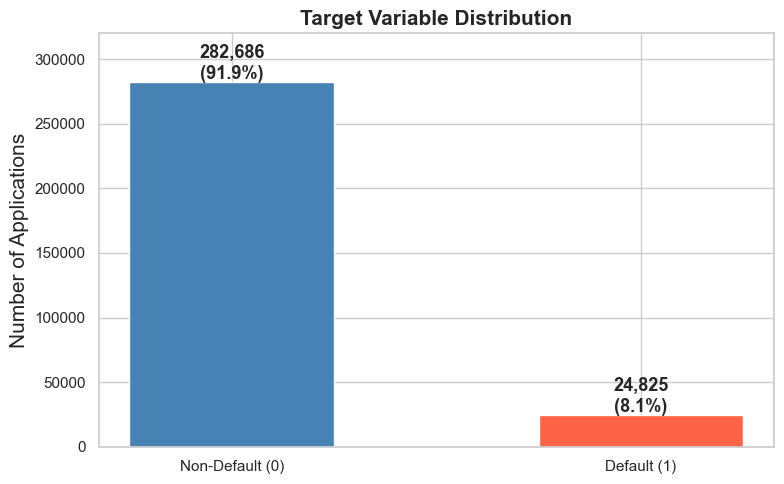

In [70]:
target_counts = df['TARGET'].value_counts()
target_pct = df['TARGET'].value_counts(normalize=True)*100

print("Target Variable Distribution")
print("="*35)
print(f"Non-Default (0): {target_counts[0]:,} ({target_pct[0]:.1f}%)")
print(f"Default     (1): {target_counts[1]:,} ({target_pct[1]:.1f}%)")
print(f"\nDefault Rate: {target_pct[1]:.2f}%")

# Visualise
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(['Non-Default (0)', 'Default (1)'], 
       target_counts.values,
       color=['steelblue', 'tomato'],
       edgecolor='white',
       width=0.5)

ax.set_title('Target Variable Distribution', fontsize=15, fontweight='bold')
ax.set_ylim(0, 320000)
ax.set_ylabel('Number of Applications', fontsize=15)

for i, v in enumerate(target_counts.values):
    ax.text(i, v + 2000, f'{v:,}\n({target_pct[i]:.1f}%)', 
            ha='center', fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

### Class Imbalance

The dataset exhibits significant class imbalance — approximately **8% of applicants default**. This is typical in retail credit portfolios and must be handled during model training (here via `class_weight='balanced'` in logistic regression).

In [71]:
# First look at the data
print("FIRST 5 ROWS — KEY COLUMNS")
print("="*50)

key_cols = ['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 
            'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY',
            'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
            'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_CHILDREN']

print(df[key_cols].head())
print(f"\nDATA TYPES")
print("="*50)
print(df.dtypes.value_counts())

FIRST 5 ROWS — KEY COLUMNS
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE   AMT_CREDIT  AMT_INCOME_TOTAL  \
0      100002       1         Cash loans  406597.5000       202500.0000   
1      100003       0         Cash loans 1293502.5000       270000.0000   
2      100004       0    Revolving loans  135000.0000        67500.0000   
3      100006       0         Cash loans  312682.5000       135000.0000   
4      100007       0         Cash loans  513000.0000       121500.0000   

   AMT_ANNUITY NAME_INCOME_TYPE            NAME_EDUCATION_TYPE  DAYS_BIRTH  \
0   24700.5000          Working  Secondary / secondary special       -9461   
1   35698.5000    State servant               Higher education      -16765   
2    6750.0000          Working  Secondary / secondary special      -19046   
3   29686.5000          Working  Secondary / secondary special      -19005   
4   21865.5000          Working  Secondary / secondary special      -19932   

   DAYS_EMPLOYED  CNT_CHILDREN  
0           -637    

In [72]:
## Check for missing data

missing_data = df.isnull().sum()
missing_data = missing_data[missing_data>0]

missing_data_pct = missing_data/len(df)*100

missing_data_df = pd.DataFrame({'missing_data': missing_data,
                                'missing_data_pct': missing_data_pct})

missing_data_df = missing_data_df.sort_values(by="missing_data_pct", ascending=False)

missing_data_df

,missing_data,missing_data_pct
COMMONAREA_MEDI,214865,69.8723
COMMONAREA_AVG,214865,69.8723
COMMONAREA_MODE,214865,69.8723
NONLIVINGAPARTMENTS_MEDI,213514,69.4330
NONLIVINGAPARTMENTS_MODE,213514,69.4330
...,...,...
EXT_SOURCE_2,660,0.2146
AMT_GOODS_PRICE,278,0.0904
AMT_ANNUITY,12,0.0039
CNT_FAM_MEMBERS,2,0.0007


### Missing Data Strategy

Features with **>50% missing values** are dropped — they carry insufficient information to be reliable predictors.

For features with ≤50% missing values:
- **Categorical features** → filled with `"unknown"` (preserves the signal that data was absent)
- **Numeric features** → filled with the **median** (robust to outliers)

In [73]:
# remove columns with more than 50% of the data missing

missing_data_rel_df = missing_data_df[missing_data_df['missing_data_pct'] <= 50]

missing_data_rel_df

,missing_data,missing_data_pct
FLOORSMAX_MEDI,153020,49.7608
FLOORSMAX_AVG,153020,49.7608
FLOORSMAX_MODE,153020,49.7608
YEARS_BEGINEXPLUATATION_AVG,150007,48.7810
YEARS_BEGINEXPLUATATION_MEDI,150007,48.7810
YEARS_BEGINEXPLUATATION_MODE,150007,48.7810
TOTALAREA_MODE,148431,48.2685
EMERGENCYSTATE_MODE,145755,47.3983
OCCUPATION_TYPE,96391,31.3455
EXT_SOURCE_3,60965,19.8253


In [74]:

alterable_data_type_df = pd.DataFrame({'Type': df.dtypes[missing_data_rel_df.index],
                  'pct_missing':missing_data_rel_df['missing_data_pct']})



In [75]:
alterable_data_type_df

,Type,pct_missing
FLOORSMAX_MEDI,float64,49.7608
FLOORSMAX_AVG,float64,49.7608
FLOORSMAX_MODE,float64,49.7608
YEARS_BEGINEXPLUATATION_AVG,float64,48.7810
YEARS_BEGINEXPLUATATION_MEDI,float64,48.7810
YEARS_BEGINEXPLUATATION_MODE,float64,48.7810
TOTALAREA_MODE,float64,48.2685
EMERGENCYSTATE_MODE,str,47.3983
OCCUPATION_TYPE,str,31.3455
EXT_SOURCE_3,float64,19.8253


In [76]:
#what columns have more than 50% of missed data. 

removable_cols = missing_data_df[missing_data_df['missing_data_pct']>50]

In [77]:
#drop those columns from the main dataset.

df=df.drop(removable_cols.index, axis=1)

In [78]:
df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_2,EXT_SOURCE_3,YEARS_BEGINEXPLUATATION_AVG,FLOORSMAX_AVG,YEARS_BEGINEXPLUATATION_MODE,FLOORSMAX_MODE,YEARS_BEGINEXPLUATATION_MEDI,FLOORSMAX_MEDI,TOTALAREA_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0000,406597.5000,24700.5000,351000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637,-3648.0000,-2120,1,1,0,1,1,0,Laborers,1.0000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.2629,0.1394,0.9722,0.0833,0.9722,0.0833,0.9722,0.0833,0.0149,No,2.0000,2.0000,2.0000,2.0000,-1134.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,100003,0,Cash loans,F,N,N,0,270000.0000,1293502.5000,35698.5000,1129500.0000,Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,-1188,-1186.0000,-291,1,1,0,1,1,0,Core staff,2.0000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.6222,NaN,0.9851,0.2917,0.9851,0.2917,0.9851,0.2917,0.0714,No,1.0000,0.0000,1.0000,0.0000,-828.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0000,135000.0000,6750.0000,135000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0100,-19046,-225,-4260.0000,-2531,1,1,1,1,1,0,Laborers,1.0000,2,2,MONDAY,9,0,0,0,0,0,0,Government,0.5559,0.7296,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,-815.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,100006,0,Cash loans,F,N,Y,0,135000.0000,312682.5000,29686.5000,297000.0000,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.0080,-19005,-3039,-9833.0000,-2437,1,1,0,1,0,0,Laborers,2.0000,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,0.6504,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0000,0.0000,2.0000,0.0000,-617.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0000,513000.0000,21865.5000,513000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0287,-19932,-3038,-4311.0000,-3458,1,1,0,1,0,0,Core staff,1.0000,2,2,THURSDAY,11,0,0,0,0,1,1,Religion,0.3227,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,-1106.0000,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [79]:
alterable_object_type_data = alterable_data_type_df[alterable_data_type_df['Type']== 'str']
alterable_numeric_type_data = alterable_data_type_df[alterable_data_type_df['Type']== 'float64']

In [80]:
df[alterable_object_type_data.index] = df[alterable_object_type_data.index].fillna("unknown")
df[alterable_numeric_type_data.index] = df[alterable_numeric_type_data.index].fillna(
                                            df[alterable_numeric_type_data.index].median()
                                            )

In [81]:
df.isnull().sum().sum()

np.int64(0)

All null values have been resolved. The dataset is now ready for feature engineering.

In [82]:
print('DAYS_EMPLOYED:')
print(df['DAYS_EMPLOYED'].describe())
print('\nDAYS_BIRTH:')
print(df['DAYS_BIRTH'].describe())

DAYS_EMPLOYED:
count   307511.0000
mean     63815.0459
std     141275.7665
min     -17912.0000
25%      -2760.0000
50%      -1213.0000
75%       -289.0000
max     365243.0000
Name: DAYS_EMPLOYED, dtype: float64

DAYS_BIRTH:
count   307511.0000
mean    -16036.9951
std       4363.9886
min     -25229.0000
25%     -19682.0000
50%     -15750.0000
75%     -12413.0000
max      -7489.0000
Name: DAYS_BIRTH, dtype: float64


`DAYS_EMPLOYED` contains an anomalous placeholder value of **365,243** (~1,000 years), which encodes unemployed applicants in the source data. This is replaced with `NaN` and imputed with the median employment duration.

`DAYS_BIRTH` (stored as negative days from today) is converted to `AGE_YEARS` for interpretability.

In [83]:
df['DAYS_EMPLOYED']= df["DAYS_EMPLOYED"].replace(365243, np.nan)
df['DAYS_EMPLOYED']= df["DAYS_EMPLOYED"].fillna(df["DAYS_EMPLOYED"].median())

In [84]:
df["AGE_YEARS"]=df["DAYS_BIRTH"]/(-365)

In [85]:
df["AGE_YEARS"].describe()

count   307511.0000
mean        43.9370
std         11.9561
min         20.5178
25%         34.0082
50%         43.1507
75%         53.9233
max         69.1205
Name: AGE_YEARS, dtype: float64

### Univariate Analysis

We examine the distribution of key features split by default outcome to identify early predictive signals before formal feature selection.

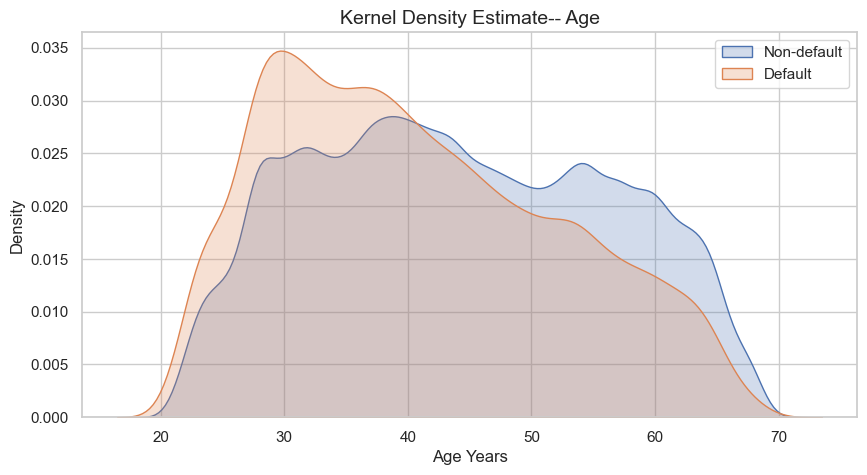

In [86]:
#visualize -- univariate analysis

non_def_age = df[df['TARGET']==0]['AGE_YEARS']
def_age = df[df['TARGET']==1]['AGE_YEARS']

plt.figure(figsize=(10, 5))
sns.kdeplot(non_def_age, label="Non-default", fill=True)
sns.kdeplot(def_age, label='Default', fill=True)
plt.legend()
plt.xlabel("Age Years")
plt.title("Kernel Density Estimate-- Age", fontsize=14)
plt.show()


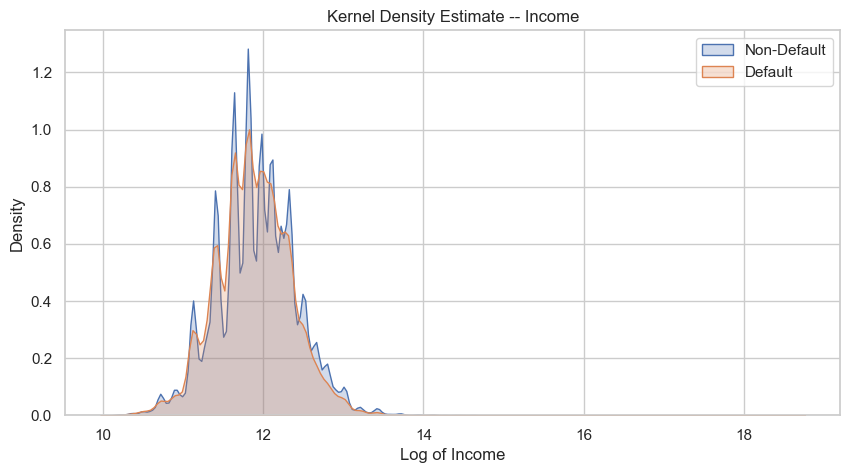

In [87]:
non_def_income = np.log(df[df['TARGET']==0]['AMT_INCOME_TOTAL'])
def_income = np.log(df[df['TARGET']==1]['AMT_INCOME_TOTAL'])

plt.figure(figsize=(10, 5))
sns.kdeplot(non_def_income, label='Non-Default', fill=True)
sns.kdeplot(def_income, label='Default', fill=True)
plt.legend()
plt.xlabel("Log of Income")
plt.title("Kernel Density Estimate -- Income")
plt.show()

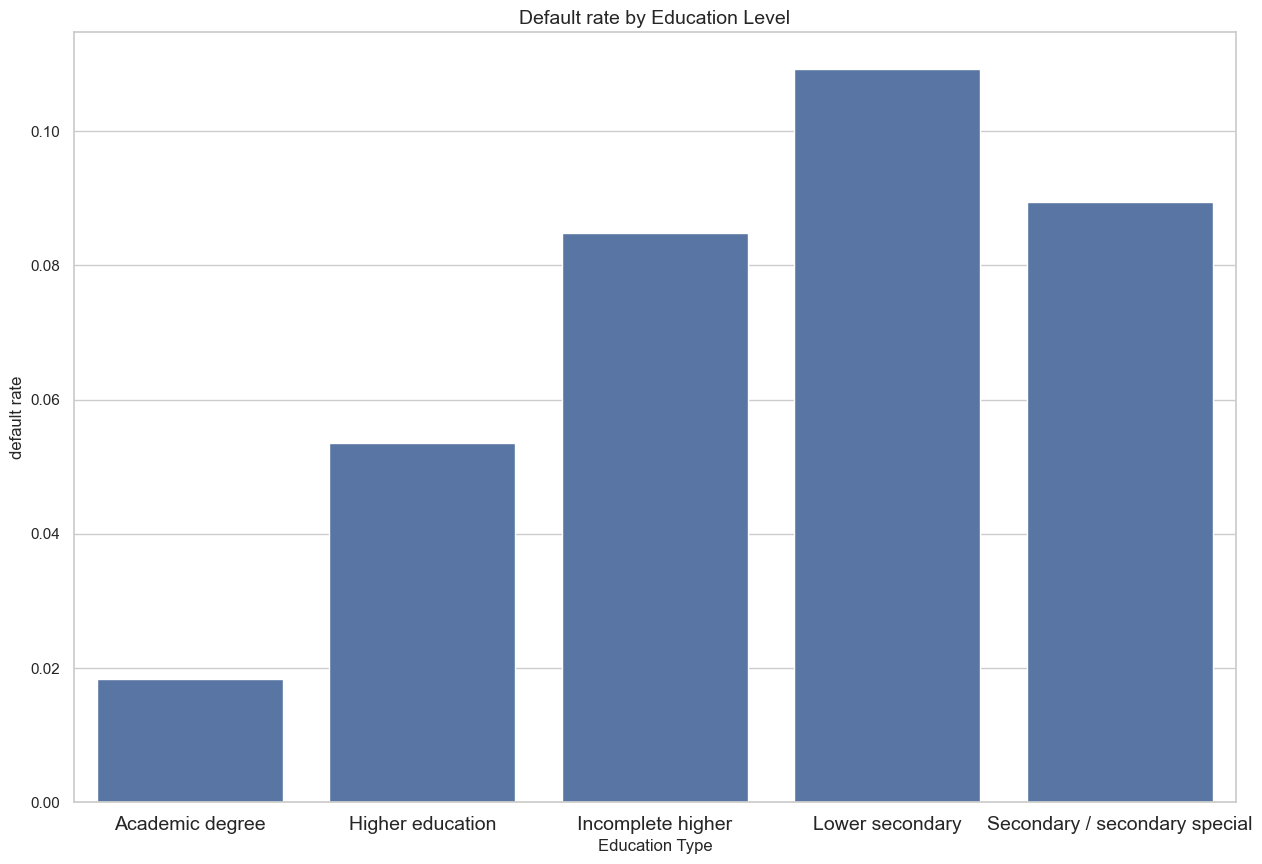

In [88]:
def_rate_education = df.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean()

plt.figure(figsize=(15,10))
sns.barplot(def_rate_education)
plt.ylabel("default rate")
plt.xticks(fontsize=14)
plt.xlabel("Education Type")
plt.title("Default rate by Education Level", fontsize=14)
plt.show()

In [89]:
df.groupby('NAME_EDUCATION_TYPE')['TARGET'].agg(['mean', 'count'])

,mean,count
NAME_EDUCATION_TYPE,,
Academic degree,0.0183,164
Higher education,0.0536,74863
Incomplete higher,0.0848,10277
Lower secondary,0.1093,3816
Secondary / secondary special,0.0894,218391


Applicants with lower educational attainment show higher default rates. Those with *Lower secondary* education have the highest default risk, while *Academic degree* holders default least. However, group sizes vary substantially, so these rates should be interpreted alongside counts.

## Feature Engineering

### Weight of Evidence (WoE) & Information Value (IV)

WoE and IV are standard credit scoring techniques for feature transformation and selection.

**Weight of Evidence (WoE)** quantifies the log-odds ratio between defaulters and non-defaulters within each feature bin:

$$WoE_i = \ln\left(\frac{\%\,\text{Defaulters}_i}{\%\,\text{Non-Defaulters}_i}\right)$$

**Information Value (IV)** aggregates WoE across all bins to measure a feature's total predictive power:

$$IV = \sum_i \left(\%D_i - \%ND_i\right) \times WoE_i$$

| IV Range | Predictive Power |
|---|---|
| < 0.02 | Unpredictive |
| 0.02 – 0.1 | Weak |
| 0.1 – 0.3 | Medium |
| > 0.3 | Strong |

Features with **IV > 0.02** are selected for modelling. WoE-transformed values replace raw feature values as model inputs.

In [90]:
## deciding on what to include/exclude to help predict TARGET
## seeing what the columns were

df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_2,EXT_SOURCE_3,YEARS_BEGINEXPLUATATION_AVG,FLOORSMAX_AVG,YEARS_BEGINEXPLUATATION_MODE,FLOORSMAX_MODE,YEARS_BEGINEXPLUATATION_MEDI,FLOORSMAX_MEDI,TOTALAREA_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS
0,100002,1,Cash loans,M,N,Y,0,202500.0000,406597.5000,24700.5000,351000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637.0000,-3648.0000,-2120,1,1,0,1,1,0,Laborers,1.0000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.2629,0.1394,0.9722,0.0833,0.9722,0.0833,0.9722,0.0833,0.0149,No,2.0000,2.0000,2.0000,2.0000,-1134.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,25.9205
1,100003,0,Cash loans,F,N,N,0,270000.0000,1293502.5000,35698.5000,1129500.0000,Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,-1188.0000,-1186.0000,-291,1,1,0,1,1,0,Core staff,2.0000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.6222,0.5353,0.9851,0.2917,0.9851,0.2917,0.9851,0.2917,0.0714,No,1.0000,0.0000,1.0000,0.0000,-828.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,45.9315
2,100004,0,Revolving loans,M,Y,Y,0,67500.0000,135000.0000,6750.0000,135000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0100,-19046,-225.0000,-4260.0000,-2531,1,1,1,1,1,0,Laborers,1.0000,2,2,MONDAY,9,0,0,0,0,0,0,Government,0.5559,0.7296,0.9816,0.1667,0.9816,0.1667,0.9816,0.1667,0.0688,unknown,0.0000,0.0000,0.0000,0.0000,-815.0000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,52.1808
3,100006,0,Cash loans,F,N,Y,0,135000.0000,312682.5000,29686.5000,297000.0000,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.0080,-19005,-3039.0000,-9833.0000,-2437,1,1,0,1,0,0,Laborers,2.0000,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,0.6504,0.5353,0.9816,0.1667,0.9816,0.1667,0.9816,0.1667,0.0688,unknown,2.0000,0.0000,2.0000,0.0000,-617.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,52.0685
4,100007,0,Cash loans,M,N,Y,0,121500.0000,513000.0000,21865.5000,513000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0287,-19932,-3038.0000,-4311.0000,-3458,1,1,0,1,0,0,Core staff,1.0000,2,2,THURSDAY,11,0,0,0,0,1,1,Religion,0.3227,0.5353,0.9816,0.1667,0.9816,0.1667,0.9816,0.1667,0.0688,unknown,0.0000,0.0000,0.0000,0.0000,-1106.0000,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,54.6082


In [91]:
exclude_cols = ['SK_ID_CURR', 'CODE_GENDER', 'TARGET']

feature_cols = [col for col in df.columns if col not in exclude_cols]


def_count = df.groupby('NAME_EDUCATION_TYPE')["TARGET"].sum()
non_def_count = df.groupby('NAME_EDUCATION_TYPE')["TARGET"].count() - def_count

total_defaulters = df['TARGET'].sum()
total_non_defaulters = df['TARGET'].count() - total_defaulters

In [92]:
def_count_rate = def_count / total_defaulters
non_def_count_rate = non_def_count / total_non_defaulters

In [93]:
woe= np.log(def_count/non_def_count)

In [94]:

def woe_iv(df, feature: object , total_defaulters, total_non_defaulters):
    if df[feature].dtype == 'str':
        def_count = df.groupby(f'{feature}')["TARGET"].sum()
        non_def_count = df.groupby(f'{feature}')["TARGET"].count() - def_count
    else:
        feature_bins = pd.qcut(df[feature], q=10, duplicates='drop')
    
        def_count = df.groupby(feature_bins)["TARGET"].sum()
        non_def_count = df.groupby(feature_bins)["TARGET"].count() - def_count
    
    def_count_rate = (def_count+0.5) / total_defaulters                 #laplace smoothing to avoid probs with log
    non_def_count_rate = (non_def_count+0.5) / total_non_defaulters

    woe= np.log(def_count_rate/non_def_count_rate)

    iv = ((def_count_rate - non_def_count_rate) * woe).sum()


    return woe, iv

                   


In [95]:
iv_results = []
woe_iv_results = []

for feature in feature_cols:
    woe, iv = woe_iv(df, feature, total_defaulters, total_non_defaulters)
    iv_results.append({'feature': feature, 'iv': iv})
    woe_iv_results.append({'feature': feature, 'woe':woe, 'iv':iv})

iv_df = pd.DataFrame(iv_results).sort_values('iv', ascending=False)

woe_iv_df = pd.DataFrame((woe_iv_results))

In [96]:
sig_features = woe_iv_df.sort_values(by = "iv", ascending=False).reset_index(drop=True)

sig_features = sig_features[sig_features["iv"]>0.02]

sig_features = sig_features["feature"].to_list()

In [97]:
sig_features

['EXT_SOURCE_3',
 'EXT_SOURCE_2',
 'DAYS_EMPLOYED',
 'AMT_GOODS_PRICE',
 'DAYS_BIRTH',
 'AGE_YEARS',
 'OCCUPATION_TYPE',
 'ORGANIZATION_TYPE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'DAYS_LAST_PHONE_CHANGE',
 'AMT_CREDIT',
 'DAYS_ID_PUBLISH',
 'REGION_POPULATION_RELATIVE',
 'TOTALAREA_MODE',
 'REGION_RATING_CLIENT_W_CITY',
 'FLOORSMAX_AVG',
 'REGION_RATING_CLIENT',
 'FLOORSMAX_MEDI',
 'DAYS_REGISTRATION',
 'AMT_ANNUITY',
 'FLOORSMAX_MODE',
 'YEARS_BEGINEXPLUATATION_MEDI',
 'YEARS_BEGINEXPLUATATION_MODE',
 'YEARS_BEGINEXPLUATATION_AVG',
 'EMERGENCYSTATE_MODE',
 'NAME_FAMILY_STATUS']

In [98]:
def transform_woe(df, woe_iv_results, sig_features):
    df_woe = df[sig_features].copy()
    
    # Build a lookup dictionary from woe_iv_results
    woe_lookup = {row['feature']: row['woe'] for row in woe_iv_results 
                  if row['feature'] in sig_features}
    
    for feature in sig_features:
        woe_map = woe_lookup[feature]
        
        if df[feature].dtype == 'str':
            # Categorical — direct map
            df_woe[feature] = df[feature].map(woe_map)
        else:
            # Numerical — bin first using same quantile bins, then map
            feature_bins = pd.qcut(df[feature], q=10, 
                                   duplicates='drop')
            df_woe[feature] = feature_bins.map(woe_map)
    
    return df_woe

# Apply transformation
df_woe = transform_woe(df, woe_iv_results, sig_features)

print(f"WoE transformed dataset shape: {df_woe.shape}")
df_woe.head()

WoE transformed dataset shape: (307511, 27)


,EXT_SOURCE_3,EXT_SOURCE_2,DAYS_EMPLOYED,AMT_GOODS_PRICE,DAYS_BIRTH,AGE_YEARS,OCCUPATION_TYPE,ORGANIZATION_TYPE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,DAYS_LAST_PHONE_CHANGE,AMT_CREDIT,DAYS_ID_PUBLISH,REGION_POPULATION_RELATIVE,TOTALAREA_MODE,REGION_RATING_CLIENT_W_CITY,FLOORSMAX_AVG,REGION_RATING_CLIENT,FLOORSMAX_MEDI,DAYS_REGISTRATION,AMT_ANNUITY,FLOORSMAX_MODE,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BEGINEXPLUATATION_MODE,YEARS_BEGINEXPLUATATION_AVG,EMERGENCYSTATE_MODE,NAME_FAMILY_STATUS
0,0.9745,0.4480,0.3876,0.2445,0.3998,0.3988,0.2981,0.1550,0.1887,0.1115,-0.1292,0.2391,0.1150,0.1722,0.1040,-0.0771,0.0889,-0.0787,0.0863,0.0812,0.0530,0.0867,0.0001,-0.0042,-0.0034,-0.1596,0.2138
1,0.0379,-0.3426,0.2113,-0.5305,-0.0382,-0.0379,-0.2661,-0.3334,-0.3630,-0.4395,0.0235,-0.4447,0.2539,0.0657,-0.1286,-0.0771,-0.3018,-0.0787,-0.3008,0.1244,0.0690,-0.3034,-0.1874,-0.1763,-0.1935,-0.1596,-0.0712
2,-0.8014,-0.0861,0.3359,-0.1108,-0.2601,-0.2596,0.2981,-0.1569,0.1887,0.1115,0.0235,-0.1975,0.1150,-0.0484,0.1187,-0.0771,0.0708,-0.0787,0.0692,0.0812,-0.1380,0.0652,0.1202,0.1200,0.1200,0.1503,0.2138
3,0.0379,-0.5330,-0.1257,0.2445,-0.2601,-0.2596,0.2981,0.1550,0.1887,0.1115,0.1615,0.2391,0.1150,0.1553,0.1187,-0.0771,0.0708,-0.0787,0.0692,-0.2133,0.2444,0.0652,0.1202,0.1200,0.1200,0.1503,0.2292
4,0.0379,0.4480,-0.1257,-0.2265,-0.2601,-0.2596,-0.2661,-0.2510,0.1887,0.1115,-0.1292,0.1889,-0.0397,-0.0838,0.1187,-0.0771,0.0708,-0.0787,0.0692,0.0812,0.0802,0.0652,0.1202,0.1200,0.1200,0.1503,0.2138


In [99]:
sig_vars = iv_df[iv_df['iv'] > 0.02]

sig_features = sig_vars['feature'].tolist()

len(sig_features)

27

In [100]:
iv_top20 = iv_df.sort_values(by='iv', ascending=False).head(20).reset_index(drop=True)

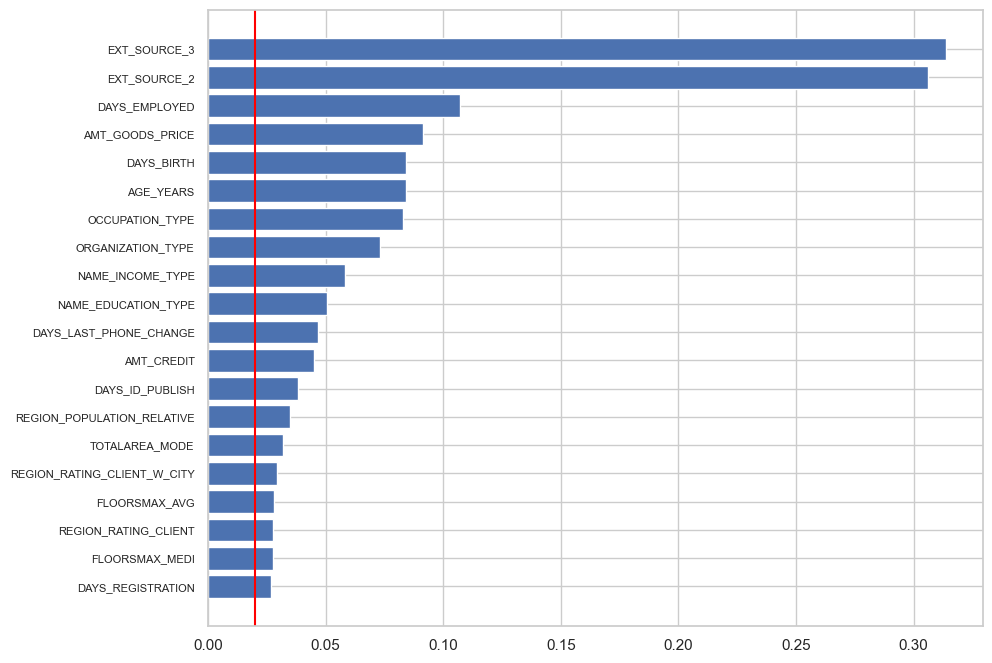

In [101]:
plt.figure(figsize=(10, 8))
plt.barh(iv_top20['feature'], iv_top20['iv'])
plt.axvline(x=0.02, color="red")
plt.gca().invert_yaxis()
plt.yticks(fontsize=8)
plt.show()

The top 20 features by IV are dominated by `EXT_SOURCE_1/2/3` — external credit bureau scores — followed by loan annuity-to-credit ratios and applicant age. The red vertical line marks the IV = 0.02 inclusion threshold.

### Model building

We train a **Logistic Regression** model on the WoE-transformed feature set. Logistic regression is the industry standard for PD scorecards because:

- Coefficients map directly to score points via the log-odds relationship
- The model is fully interpretable and auditable (Basel III, SR 11-7)
- WoE transformation linearises the feature–log-odds relationship

`class_weight='balanced'` reweights the loss function to account for the ~8% default rate imbalance.

In [102]:
from numpy import shape

X_train, X_test, y_train, y_test = train_test_split(df_woe, df['TARGET'],
                                                    test_size=0.2,
                                                    random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Training default rate: {y_train.mean():.3f}")
print(f"Test default rate: {y_test.mean():.3f}")

Training set: (246008, 27)
Test set: (61503, 27)
Training default rate: 0.081
Test default rate: 0.080


In [103]:
model_LR = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

model_LR.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [104]:
PD_LR=model_LR.predict_proba(X_test)[:,1]
PND_LR= model_LR.predict_proba(X_test)[:,0]

In [105]:
AUC_roc_score = roc_auc_score(y_test, PD_LR)

gini_coeff = 2 * AUC_roc_score -1

print(f"Area under ROC:", AUC_roc_score, f"Gini coefficient:", gini_coeff)

Area under ROC: 0.7348100106534186 Gini coefficient: 0.4696200213068371


### Model Performance

| Metric | Description | Benchmark |
|---|---|---|
| **AUC-ROC** | Probability that the model ranks a random defaulter above a random non-defaulter | > 0.7 good |
| **Gini** | 2 × AUC − 1; normalised discrimination measure | > 0.4 acceptable, > 0.6 good |
| **KS Statistic** | Maximum separation between defaulter and non-defaulter score CDFs | > 0.3 acceptable |

In [106]:
from scipy.stats import ks_2samp

scores_default = PD_LR[y_test == 1]      # PD scores for actual defaulters
scores_non_default = PD_LR[y_test == 0]  # PD scores for actual non-defaulters

ks_stat, p_value = ks_2samp(scores_default, scores_non_default)

print("KS:", ks_stat)
print("p-value:", p_value)

KS: 0.34623687481391063
p-value: 0.0


Text(0.5, 1.0, 'ROC Curve')

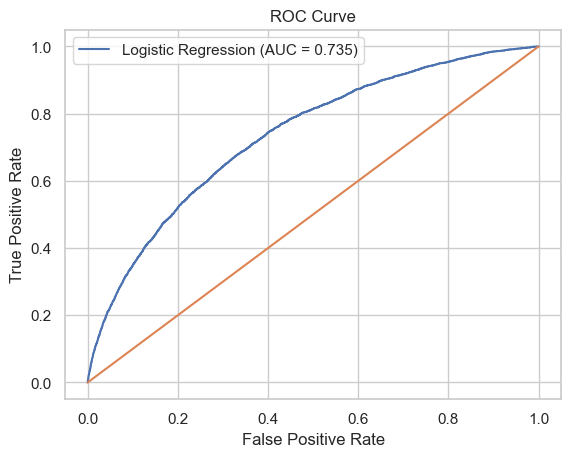

In [107]:
fpr, tpr, thresholds = roc_curve(y_test, PD_LR)


plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {AUC_roc_score:.3f})')
plt.plot(np.linspace(0, 1,100), np.linspace(0,1,100))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ROC Curve")


The ROC curve bows well above the 0.5 diagonal (random classifier baseline), confirming meaningful discrimination between defaulters and non-defaulters.

In [108]:
LR_coefficients = model_LR.coef_
LR_intercept = model_LR.intercept_

LR_coefficients = pd.Series(model_LR.coef_[0], index=sig_features)
print(f"Coefficient", LR_coefficients.shape)
print(f"Intercepts", LR_intercept.shape)

Coefficient (27,)
Intercepts (1,)


### Scorecard Scaling

The logistic regression probability estimates are converted to an integer **credit score** using standard industry scaling:

$$\text{Score} = \text{Offset} + \text{Factor} \times \ln(\text{Odds})$$

Where:
- **PDO = 20** — a 20-point score increase halves the default risk (industry convention)
- **Base Score = 600** — anchors the scale at a FICO-style reference point
- **Base Odds = 50:1** — 50 non-defaulters per defaulter at the base score

Each feature bin contributes a fixed number of **scorecard points** derived from its WoE value and the corresponding logistic regression coefficient.

In [109]:
# Scorecard scaling parameters
PDO = 20          # points to double the odds - industry standard
BASE_SCORE = 600  # base score - typical FICO-style starting point
BASE_ODDS = 50    # odds of non-default:default at base score (50:1)

def fac_offst(BASE_SCORE, BASE_ODDS, PDO):
    f = PDO/np.log(2)
    ofst = BASE_SCORE - f * np.log(BASE_ODDS)
    return f, ofst

factor, offset = fac_offst(BASE_SCORE, BASE_ODDS, PDO)

print(f'Factor=', factor)
print(f"Offset=", offset)

Factor= 28.85390081777927
Offset= 487.1228762045055


In [110]:
# Convert list of dicts into a simple feature -> woe lookup
woe_lookup = {row['feature']: row['woe'] for row in woe_iv_results 
              if row['feature'] in sig_features}

woe_lookup

{'AMT_CREDIT': AMT_CREDIT
 (44999.999, 180000.0]    -0.1975
 (180000.0, 254700.0]     -0.0403
 (254700.0, 306306.0]      0.0181
 (306306.0, 432000.0]      0.2391
 (432000.0, 513531.0]      0.1889
 (513531.0, 604152.0]      0.2921
 (604152.0, 755190.0]      0.0610
 (755190.0, 900000.0]     -0.1418
 (900000.0, 1133748.0]    -0.1722
 (1133748.0, 4050000.0]   -0.4447
 Name: TARGET, dtype: float64,
 'AMT_ANNUITY': AMT_ANNUITY
 (1615.499, 11074.5]   -0.1380
 (11074.5, 14701.5]    -0.1865
 (14701.5, 18189.0]     0.0535
 (18189.0, 21870.0]     0.0802
 (21870.0, 24903.0]     0.0530
 (24903.0, 28062.0]     0.1320
 (28062.0, 32004.0]     0.2444
 (32004.0, 37516.5]     0.0690
 (37516.5, 45954.0]    -0.0623
 (45954.0, 258025.5]   -0.3579
 Name: TARGET, dtype: float64,
 'AMT_GOODS_PRICE': AMT_GOODS_PRICE
 (40499.999, 180000.0]    -0.1108
 (180000.0, 225000.0]      0.1078
 (225000.0, 270000.0]     -0.0467
 (270000.0, 378000.0]      0.2445
 (378000.0, 450000.0]      0.5523
 (450000.0, 522000.0]     -0

In [111]:
scorecard = []

for i, feature in enumerate(sig_features):
    woe_series = woe_lookup[feature]      # WoE for each bin of this feature
    coef = LR_coefficients[feature]           # single coefficient for this feature
    n = len(sig_features)                  # number of features = 27
    
    # Apply the points formula to every bin at once
    points = -(woe_series * coef + model_LR.intercept_[0] / n) * factor + offset / n
    
    # Store the results
    for bin_label, point_value in zip(woe_series.index, points):
        scorecard.append({
            'feature': feature,
            'bin': bin_label,
            'woe': woe_series[bin_label],
            'points': point_value
        })

scorecard_df = pd.DataFrame(scorecard)

In [112]:
scorecard_df.head(20)

,feature,bin,woe,points
0,EXT_SOURCE_3,"(-0.000473, 0.257]",0.9745,-6.2652
1,EXT_SOURCE_3,"(0.257, 0.371]",0.3693,8.8337
2,EXT_SOURCE_3,"(0.371, 0.458]",0.0639,16.4527
3,EXT_SOURCE_3,"(0.458, 0.535]",0.0379,17.1012
4,EXT_SOURCE_3,"(0.535, 0.537]",-0.3425,26.5910
5,EXT_SOURCE_3,"(0.537, 0.604]",-0.4472,29.2010
6,EXT_SOURCE_3,"(0.604, 0.669]",-0.6212,33.5436
7,EXT_SOURCE_3,"(0.669, 0.735]",-0.8014,38.0371
8,EXT_SOURCE_3,"(0.735, 0.896]",-0.9578,41.9396
9,EXT_SOURCE_2,"(-0.0009999183, 0.216]",0.9387,-2.3705


Each row represents one bin of one feature. The `points` column is the score contribution for applicants falling into that bin. An applicant's **total score** is the sum of points across all features plus the offset.

In [113]:
scorecard_df[scorecard_df['feature'] == 'EXT_SOURCE_2'].set_index('woe')['points'].to_dict()

{0.9386763137366042: -2.370522259729775,
 0.44799593705114527: 8.301965344665359,
 0.2294670898780907: 13.055052126760629,
 0.03331241624073718: 17.32149199761937,
 -0.0861326727115735: 19.919468790293475,
 -0.21018703583167908: 22.61769907538018,
 -0.34264567534161994: 25.498725616148263,
 -0.5329584868495982: 29.638102730628816,
 -0.6962084691860394: 33.18885286388766,
 -1.0514648257808408: 40.91581575519366}

### Applying the Scorecard

We score all applicants in the test set by mapping each feature value to its WoE bin and summing the scorecard points.

In [114]:
scores = pd.Series(np.zeros(len(X_test)), index=X_test.index)

for feature in sig_features:
    woe_to_points = scorecard_df[scorecard_df['feature'] == f'{feature}'].set_index('woe')['points'].to_dict()
    feature_points = X_test[feature].map(woe_to_points)
    scores += feature_points.astype(float)
scores+= offset
#X_test[f'{feature}'] 

In [115]:
pd.Series(scores).describe()

count   61503.0000
mean      983.3247
std        25.6000
min       894.9488
25%       965.7728
50%       983.8665
75%      1001.4402
max      1063.6446
dtype: float64

In [116]:
scores_series = pd.Series(scores.values, index=X_test.index)

print(f"Average score - Non-defaulters: {scores_series[y_test==0].mean():.1f}")
print(f"Average score - Defaulters:     {scores_series[y_test==1].mean():.1f}")

Average score - Non-defaulters: 985.1
Average score - Defaulters:     963.1


In [117]:
scores_series.head(5)

245895    939.8697
98194    1008.7009
36463     947.9028
249923   1020.5695
158389    978.5146
dtype: float64

In [118]:
def_scores = scores_series[y_test == 1]
non_def_scores = scores_series[y_test == 0]

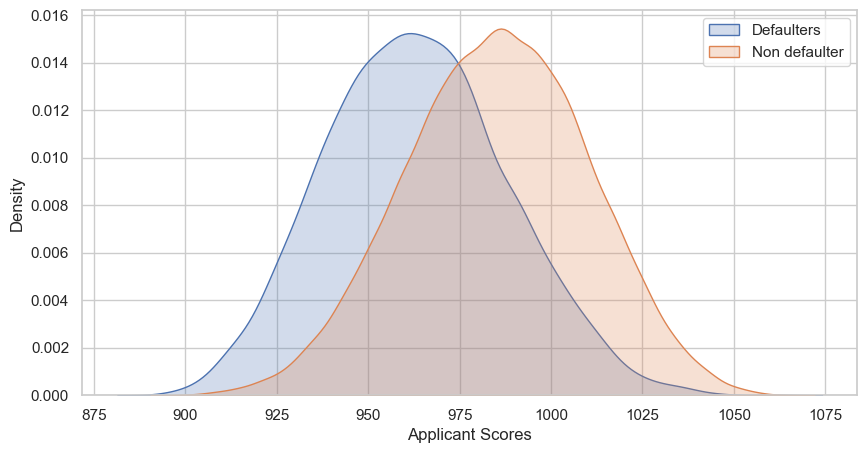

In [119]:
plt.figure(figsize=(10,5))
sns.kdeplot(def_scores, fill=True, label='Defaulters')
sns.kdeplot(non_def_scores, fill=True, label='Non defaulter')
plt.xlabel("Applicant Scores")
plt.legend()

The score distributions show clear separation: defaulters cluster at **lower scores** and non-defaulters concentrate at **higher scores**, confirming the scorecard's discriminatory power.

## Population Stability Index (PSI)

**Population Stability Index (PSI)** measures whether the score distribution has shifted between a reference population and a comparison population — a key monitoring metric for deployed credit models.

$$PSI = \sum_i \left(\%\text{Test}_i - \%\text{Train}_i\right) \times \ln\left(\frac{\%\text{Test}_i}{\%\text{Train}_i}\right)$$

| PSI | Interpretation |
|---|---|
| < 0.1 | Stable — no action required |
| 0.1 – 0.2 | Moderate shift — monitor closely |
| > 0.2 | Significant shift — model recalibration required |

We score the **training set** as the reference distribution and compare it to the **test set**.

In [120]:
## Scoring the training set
psi_scores = pd.Series(np.zeros(len(X_train)), index=X_train.index)

for feature in sig_features:
    woe_to_points_psi = scorecard_df[scorecard_df['feature'] == f'{feature}'].set_index('woe')['points'].to_dict()
    feature_points_psi = X_train[feature].map(woe_to_points_psi)
    psi_scores += feature_points_psi.astype(float)
psi_scores+= offset

In [121]:
psi_scores.describe()

count   246008.0000
mean       983.4986
std         25.6340
min        893.0961
25%        965.8446
50%        983.9799
75%       1001.6560
max       1080.1039
dtype: float64

In [122]:
psi_scores.head(10)

123473   1001.4084
10118     976.1982
64716     987.2999
234940    973.3103
236051    976.9417
30611    1007.9765
871      1010.7024
153082    989.3059
188110   1003.3260
278046    979.3726
dtype: float64

In [123]:
training_bins, bin_edges = pd.qcut(psi_scores, q=10, retbins=True, duplicates='drop')

In [124]:
binned_test = pd.cut(scores, bin_edges)
binned_train = pd.cut(psi_scores, bin_edges)

In [125]:
test_counts = binned_test.value_counts(sort=False)
test_counts

(893.096, 949.75]       6217
(949.75, 961.414]       6200
(961.414, 969.852]      6096
(969.852, 977.152]      6284
(977.152, 983.98]       6078
(983.98, 990.803]       6266
(990.803, 997.825]      6064
(997.825, 1005.893]     6276
(1005.893, 1016.543]    5936
(1016.543, 1080.104]    6086
Name: count, dtype: int64

In [126]:
train_counts = binned_train.value_counts(sort=False)
train_counts

(893.096, 949.75]       24600
(949.75, 961.414]       24601
(961.414, 969.852]      24601
(969.852, 977.152]      24600
(977.152, 983.98]       24601
(983.98, 990.803]       24601
(990.803, 997.825]      24600
(997.825, 1005.893]     24601
(1005.893, 1016.543]    24601
(1016.543, 1080.104]    24601
Name: count, dtype: int64

In [127]:
train_pct = train_counts/len(psi_scores)
train_pct

(893.096, 949.75]      0.1000
(949.75, 961.414]      0.1000
(961.414, 969.852]     0.1000
(969.852, 977.152]     0.1000
(977.152, 983.98]      0.1000
(983.98, 990.803]      0.1000
(990.803, 997.825]     0.1000
(997.825, 1005.893]    0.1000
(1005.893, 1016.543]   0.1000
(1016.543, 1080.104]   0.1000
Name: count, dtype: float64

In [128]:
test_pct = test_counts/len(scores)
test_pct

(893.096, 949.75]      0.1011
(949.75, 961.414]      0.1008
(961.414, 969.852]     0.0991
(969.852, 977.152]     0.1022
(977.152, 983.98]      0.0988
(983.98, 990.803]      0.1019
(990.803, 997.825]     0.0986
(997.825, 1005.893]    0.1020
(1005.893, 1016.543]   0.0965
(1016.543, 1080.104]   0.0990
Name: count, dtype: float64

In [129]:
psi_values = (train_pct - test_pct) * np.log(train_pct / test_pct)

psi_total = psi_values.sum()
psi_total

np.float64(0.0003176367098744629)

The near-zero PSI of 0.0003 reflects the fact that training and test sets were randomly sampled from the same dataset. In production, PSI would be monitored monthly by comparing the development sample score distribution against recent application data. A PSI exceeding 0.2 would trigger model recalibration.

## Comparing with a Machine Learning framework - XGBoost

In [131]:
from numpy.random import RandomState
from xgboost import XGBClassifier


model_xgb = XGBClassifier(n_estimators = 100, 
                          max_depth = 4, 
                          learning_rate= 0.1, 
                          scale_pos_weight= 11, 
                          random_state = 42, 
                          eval_metric = 'auc'
                          )

X_train_xgb = X_train.astype(float)
X_test_xgb = X_test.astype(float)

model_xgb.fit(X_train_xgb, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [133]:
PD_xgb=model_xgb.predict_proba(X_test_xgb)[:,1]
PND_xgb= model_xgb.predict_proba(X_test_xgb)[:,0]

In [134]:
AUC_roc_score_xgb = roc_auc_score(y_test, PD_xgb)

gini_coeff_xgb = 2 * AUC_roc_score_xgb -1

print(f"Area under ROC (XGB):", AUC_roc_score_xgb, f"Gini coefficient XGB:", gini_coeff_xgb)

Area under ROC (XGB): 0.7404297913049134 Gini coefficient XGB: 0.48085958260982675


In [135]:
ks_stat_xgb, p_value_xgb = ks_2samp(scores_default, scores_non_default)


scores_default_xgb = PD_xgb[y_test == 1]      # PD scores for actual defaulters
scores_non_default_xgb = PD_xgb[y_test == 0]  # PD scores for actual non-defaulters

ks_stat, p_value = ks_2samp(scores_default_xgb, scores_non_default_xgb)


print("KS - XGB:", ks_stat_xgb)
print("p-value - XGB:", p_value_xgb)

KS - XGB: 0.34623687481391063
p-value - XGB: 0.0


We see from the above analysis that XGBoost only marginally improves the validation metrics. 

| Metric | XGBoost  | Logistic Regression | Difference | 
|---|---|---| --- |
| Area under ROC | 0.740 | 0.735| +0.005 |
| Gini coefficient| 0.481| 0.470 | +0.011
| KS statistic| 0.346 | 0.346 | 0 |

While an improvement, the minute positive difference does not warrant the use of a model which lacks explainability and might entail regulatory complexity. The reason for this marginal difference is that our analysis heavily relies on feature engineering rather than having a sophisticated model do the heavy lifting: by encoding features as WoE values, we effectively capture the nonlinearities present in the data. There is very little left for the XGBoost to improve upon. 